In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df= pd.read_pickle('../data/intermediate/tablon_analitico_preparado.pkl')
df_diario= pd.read_pickle('../data/intermediate/tablon_analitico_diario.pkl')

### Análisis de Irradiacion en plantas 1 y 2

In [3]:
df_reducido = df.loc[(df['id_inversor'] == '1BY6WEcLGh8j5v7') | (df['id_inversor'] == 'xMbIugepa2P7lBB'), 'id_planta':'temperatura_modulo_c']

In [4]:
plant_metrics = df_reducido[df_reducido['irradiacion_wh_m2'] != 0].groupby('id_planta').agg({
    'irradiacion_wh_m2' : 'mean',
    'temperatura_ambiente_c' : 'mean',
    'temperatura_modulo_c' : 'mean'
})

In [5]:
plant_metrics

,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c
id_planta,,,
p1,0.414610,27.449898,39.029826
p2,0.365784,29.097757,37.190401


In [6]:
plant_metrics.to_parquet('../data/processed/plant_metrics.parquet')

In [7]:
temp_hora_planta = df_reducido.pivot_table(
    index='hora',
    columns='id_planta',
    values='irradiacion_wh_m2',
    aggfunc='sum'
)
temp_hora_planta.head(5)

id_planta,p1,p2
hora,,
0,0.0,0.000102
1,0.0,0.000106
2,0.0,0.000115
3,0.0,0.000344
4,0.0,0.000526


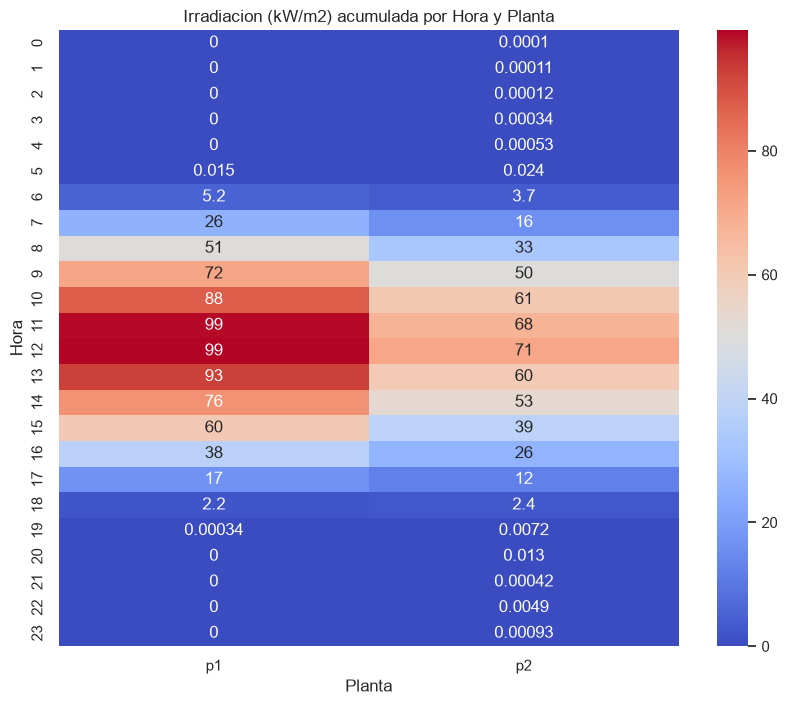

In [8]:
#heatmap sobre temp_hora_planta

plt.figure(figsize=(10, 8))
sns.heatmap(temp_hora_planta, annot=True, cmap="coolwarm")
plt.title("Irradiacion (kW/m2) acumulada por Hora y Planta")
plt.xlabel("Planta")
plt.ylabel("Hora")
plt.show()

In [9]:
temp_hora_planta_temp = df_reducido.pivot_table(
    index='hora',
    columns='id_planta',
    values='temperatura_modulo_c',
    aggfunc='mean'
)
temp_hora_planta_temp.head(5)

id_planta,p1,p2
hora,,
0,20.991789,23.549090
1,20.873304,23.283674
2,20.766690,22.934589
3,20.624820,22.765321
4,20.469069,22.703041


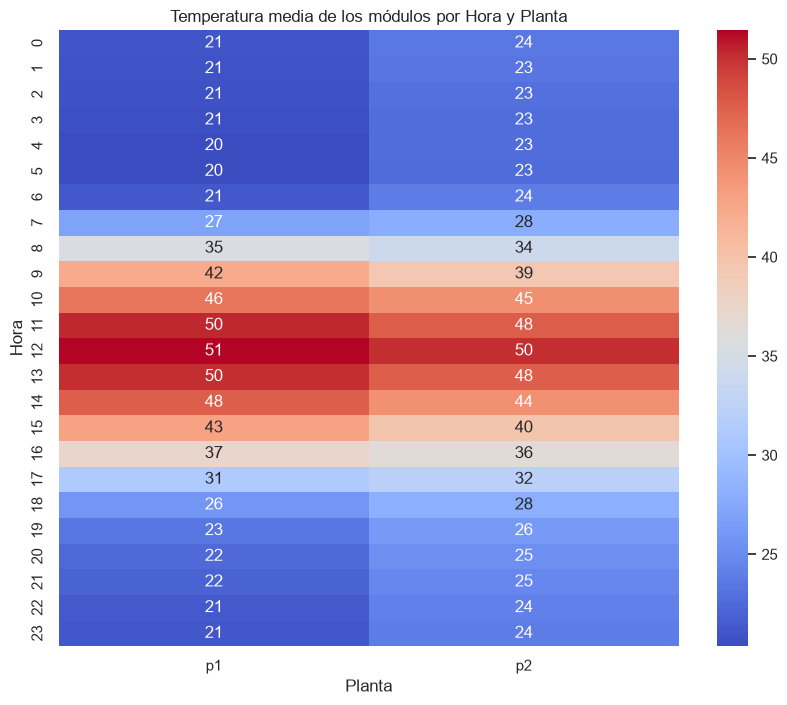

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(temp_hora_planta_temp, annot=True, cmap="coolwarm")
plt.title("Temperatura media de los módulos por Hora y Planta")
plt.xlabel("Planta")
plt.ylabel("Hora")
plt.show()

In [15]:
irradiacion_temp_p1 = df_reducido[df_reducido['id_planta'] == 'p1'].pivot_table(
    index='fecha',
    columns='hora',
    values='irradiacion_wh_m2',
    aggfunc='mean'
)

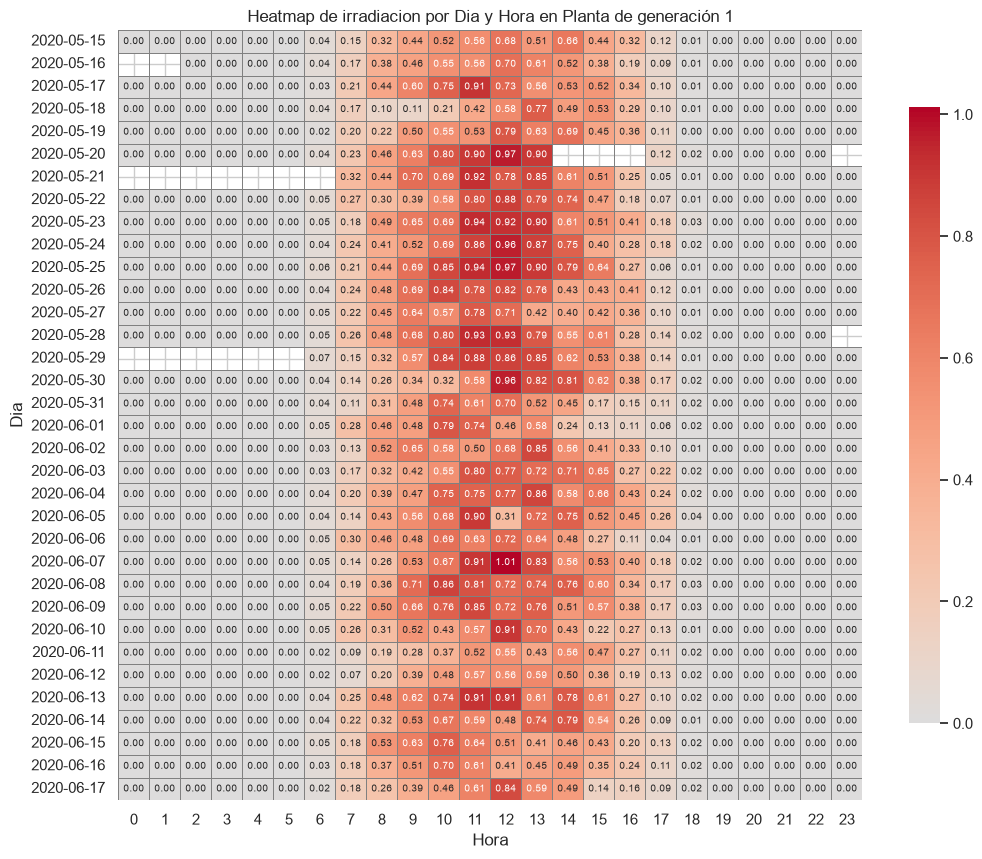

In [74]:
#heatmap de irradiacion diario por horas planta 1 (contrastar con potencia en paso posterior y detectar si las bajadas son por meteorologia/otros)

plt.figure(figsize=(12, 10))
sns.heatmap(
    irradiacion_temp_p1,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"shrink": 0.8},
    yticklabels=True,
    annot_kws={"fontsize": 7}
)
plt.title("Heatmap de irradiacion por Dia y Hora en Planta de generación 1")
plt.xlabel("Hora")
plt.ylabel("Dia")
plt.show()

In [75]:
irradiacion_temp_p2 = df_reducido[df_reducido['id_planta'] == 'p2'].pivot_table(
    index='fecha',
    columns='hora',
    values='irradiacion_wh_m2',
    aggfunc='mean'
)

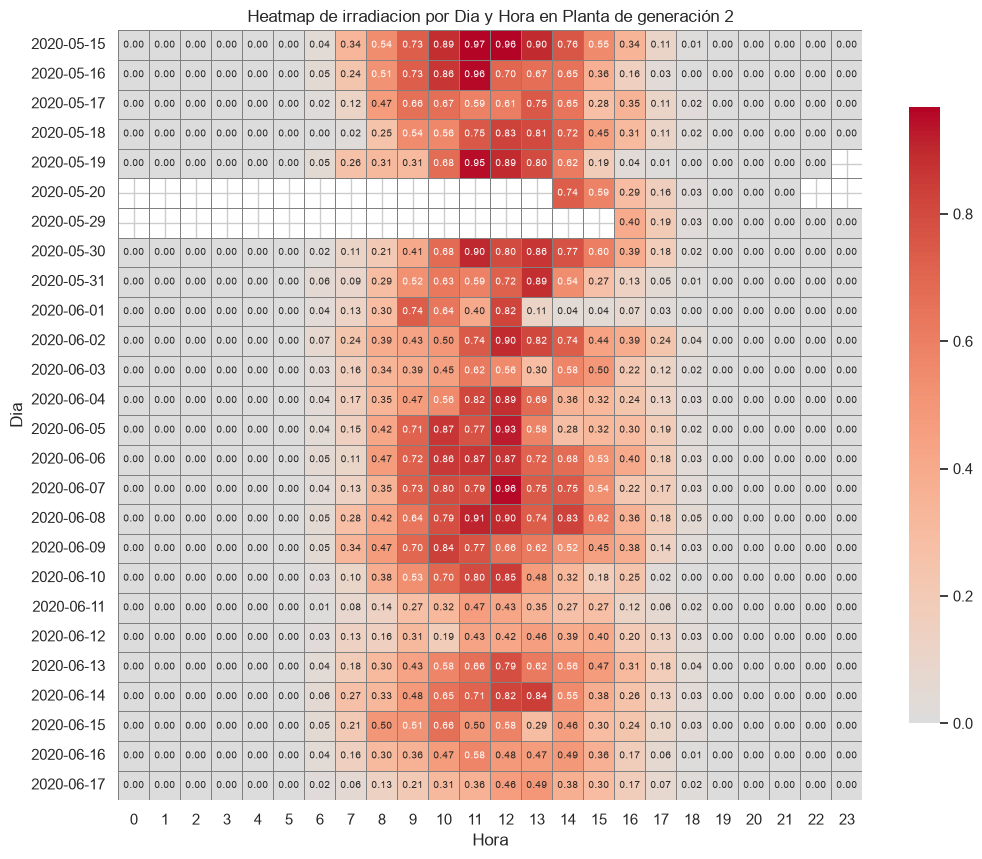

In [77]:
#heatmap de irradiacion diario por horas planta 2 (contrastar con potencia en paso posterior y detectar si las bajadas son por meteorologia/otros)

plt.figure(figsize=(12, 10))
sns.heatmap(
    irradiacion_temp_p2,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"shrink": 0.8},
    yticklabels=True,
    annot_kws={"fontsize": 7}
)
plt.title("Heatmap de irradiacion por Dia y Hora en Planta de generación 2")
plt.xlabel("Hora")
plt.ylabel("Dia")
plt.show()

### Insight 4: Analisis de irradiacion solar

Tras el analisis comparativo de las metricas de captacion  entre las plantyas p1 y p2 **se ha identificado falta de datos de captacion en ambas plantas:**
- Planta 1: falta de datos parciales los días 2020-05-16, 2020-05-20, 2020-05-21, 2020-05-28 y 2020-05-29.
- Planta 2: falta de datos parciales los días 2020-05-29, 2020-05-20 y 2020-05-29. Falta de datos completos: del 2020-05-21 al 2020-05-28.
- La ausencia de datos es aun incierta pero todo apunta a fallos en los sensores de irradiación, ya que si que se genera potencia DC.

#### Irradiacion VS potencia DC

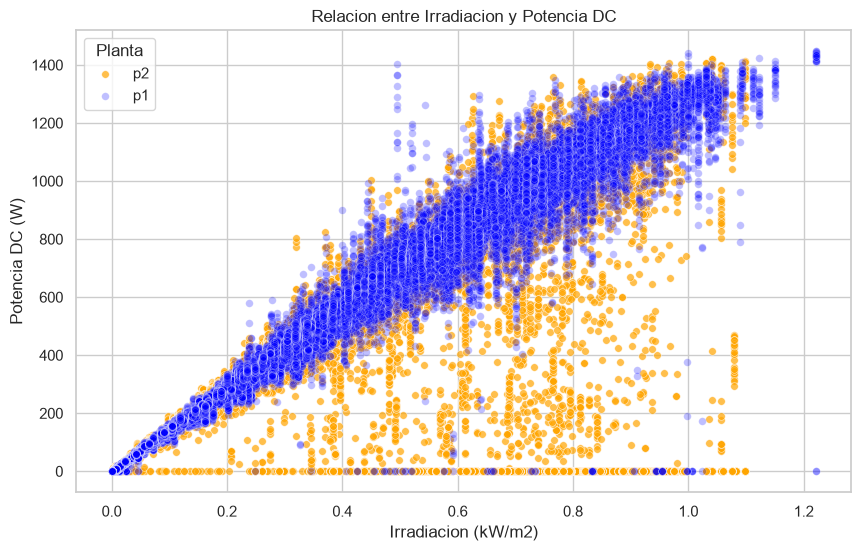

In [ ]:
# scatter entre irradiacion y potencia dc por planta
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df[df['id_planta']=='p2'],
    x='irradiacion_wh_m2',
    y='potencia_dc_kw',
    color='orange',
    alpha=0.7,
    label='p2',
    s=30
)
sns.scatterplot(
    data=df[df['id_planta']=='p1'],
    x='irradiacion_wh_m2',
    y='potencia_dc_kw',
    color='blue',
    alpha=0.25,
    label='p1',
    s=30
)

plt.legend(title='Planta')
plt.xlabel("Irradiacion (kW/m2)")
plt.ylabel("Potencia DC (kW)")
plt.title("Relacion entre Irradiacion y Potencia DC")
plt.show()

In [39]:
#potencia dc vs potencia ac en planta 2 solo en puntos anómalos (irradiacion minima y potencia umbral minima)
irradiacion_umbral = 0.2
potencia_umbral = 50

df_anomalos = df[(df['irradiacion_wh_m2'] >= irradiacion_umbral) &
                 (df['potencia_dc_kw'] <= potencia_umbral)
].copy()

#ordenar por for fecha
df_anomalos = df_anomalos.sort_values('fecha_hora')

In [40]:
df_anomalos = df_anomalos.reset_index()

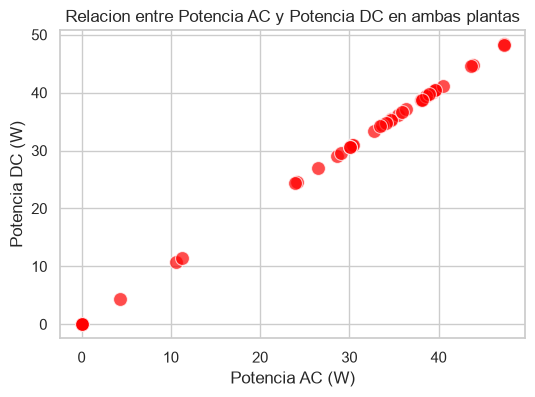

In [73]:
#scatter de potencia ac vs dc en planta 2 solo en puntos anómalos
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df_anomalos,
    x='potencia_ac_kw',
    y='potencia_dc_kw',
    color='red',
    alpha=0.7,
    s=100
)
plt.xlabel("Potencia AC (W)")
plt.ylabel("Potencia DC (W)")
plt.title("Relacion entre Potencia AC y Potencia DC en ambas plantas")
plt.show()

#### Irradiacion VS Energia generada

In [109]:
# df diario de irradiacion vs energia generada
df_diario_irradiacion_energia = (
    df
    .reset_index()
    .assign(fecha_dia=lambda x: x['fecha_hora'].dt.date)
    .groupby(['id_planta','fecha_dia'])[['irradiacion_wh_m2','energia_diaria_kwh']]
    .agg({
          'irradiacion_wh_m2': 'sum',
          'energia_diaria_kwh': 'max'
      })
    .reset_index()
)

In [189]:
df_diario_irradiacion_energia['ratio_irradiacion_energia'] = df_diario_irradiacion_energia['irradiacion_wh_m2'] / df_diario_irradiacion_energia['energia_diaria_kwh'] * 100
df_diario_irradiacion_energia[df_diario_irradiacion_energia['id_planta'] == 'p2'].head(40)

,id_planta,fecha_dia,irradiacion_wh_m2,energia_diaria_kwh,ratio_irradiacion_energia
34,p2,2020-05-15,628.299214,9663.000000,6.502113
35,p2,2020-05-16,520.884603,9465.000000,5.503271
36,p2,2020-05-17,467.139091,7722.000000,6.049457
37,p2,2020-05-18,472.907167,7818.000000,6.048953
38,p2,2020-05-19,447.597053,7696.000000,5.815970
39,p2,2020-05-20,386.608390,9511.000000,4.064855
40,p2,2020-05-21,489.441328,9423.000000,5.194114
41,p2,2020-05-22,513.645175,9873.000000,5.202524
42,p2,2020-05-23,506.879650,9863.000000,5.139204
43,p2,2020-05-24,493.668797,9688.000000,5.095673


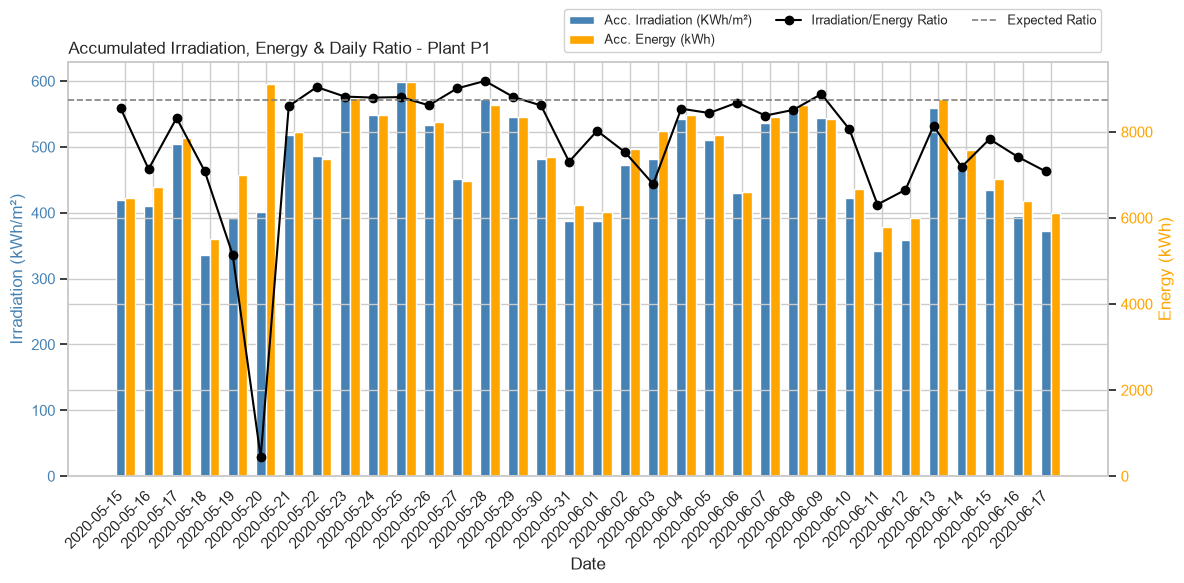

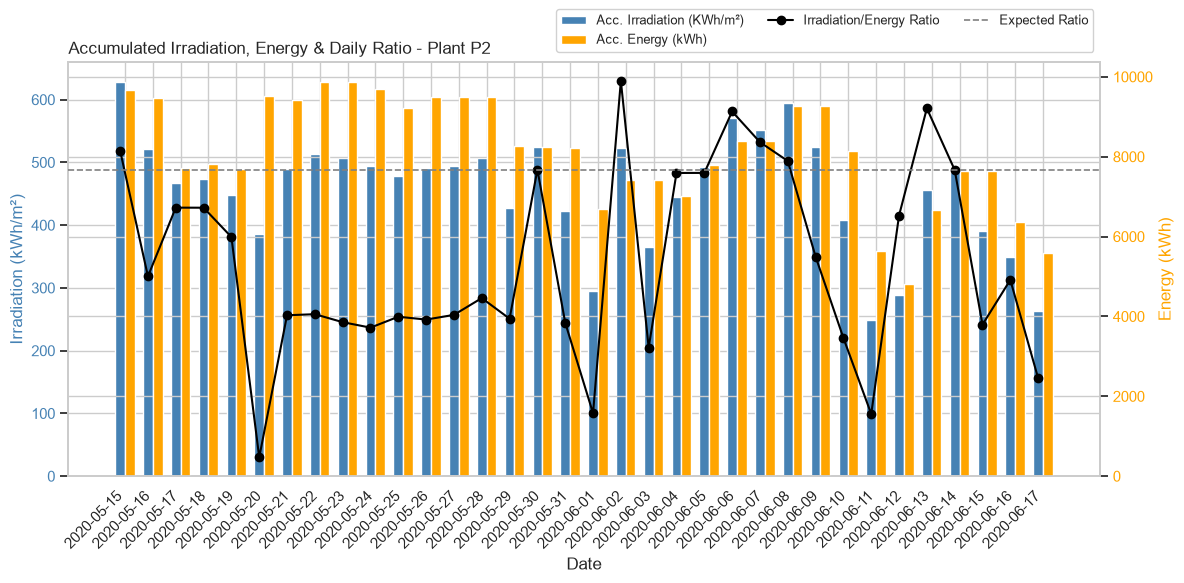

In [212]:
for planta in ['p1', 'p2']:
    df_plot = df_diario_irradiacion_energia[df_diario_irradiacion_energia['id_planta'] == planta]
    expected_ratio = {'p1': 6.52, 'p2': 6.35}

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.axis('off')

    bar_width = 0.35
    x = range(len(df_plot))

    ax1.bar(x, df_plot['irradiacion_wh_m2'], width=bar_width, label='Irradiación (Wh/m²)', color='steelblue')
    ax1.set_ylabel("Irradiation (kWh/m²)", color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')

    ax2.bar([p + bar_width for p in x], df_plot['energia_diaria_kwh'], width=bar_width, label='Energía (kWh)', color='orange')
    ax2.set_ylabel("Energy (kWh)", color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    line_ratio, = ax3.plot(x, df_plot['ratio_irradiacion_energia'], 'o-', color='black', label='Ratio Irradiación/Energía')
    line_expected = ax3.axhline(y=expected_ratio[planta], color='grey', linestyle='--', linewidth=1.2, label=f'Expected Ratio ({expected_ratio[planta]})')

    ax1.set_xlabel("Date")
    # Tick centrado entre las dos barras
    ax1.set_xticks([p + bar_width/2 for p in x])
    ax1.set_xticklabels(df_plot['fecha_dia'], rotation=45, ha='right')

    handles = [ax1.patches[0], ax2.patches[0], line_ratio, line_expected]
    labels = ['Acc. Irradiation (KWh/m²)', 'Acc. Energy (kWh)', 'Irradiation/Energy Ratio', 'Expected Ratio']
    ax1.legend(handles, labels, loc='lower right',
               bbox_to_anchor=(1.0, 1.01),  # justo debajo del título, pegado a la derecha
               ncol=3, framealpha=0.9, fontsize=9)

    ax1.set_title(f"Accumulated Irradiation, Energy & Daily Ratio - Plant {planta.upper()}", loc='left')
    plt.tight_layout()
    plt.show()

### Insight 5: Existen fallos en los sensores de medición de irradiación solar

Debido a que existen tramos sin registro de irradiación pero si existe energia generada, los fallos provienen de los equipos de medición de irradiación.

1. Planta 1: Existen ciertas anomalías entre irradiación y energia generada en los días 18, 19 y 20 de Mayo.
2. Planta 2: Se observan numerosas anomalías de medición de irradiación en diversos días. Los mas destacables son: 16 de Mayo, 20 al 29 de Mayo, 1 de Junio, 3 de Junio, 9 a 11 de Junio y 15 a 17 de Junio.


### Analisis de potencia VS Energia
Para el analisis de captacion de potencia de los inverters, lo dividiremos en dos partes: analisis diario de potencia DC vs energia generada y analisis de potencia DC de cada inverter para los días con fallos.

In [86]:
df_diario_potencia_dc = (
    df
    .reset_index()
    .assign(fecha_dia=lambda x: x['fecha_hora'].dt.date)
    .groupby(['id_planta','fecha_dia', 'hora'])[['potencia_dc_kw']]
    .mean()
    .reset_index()
)

#### Comprovacion potencia DC Planta 1 y 2

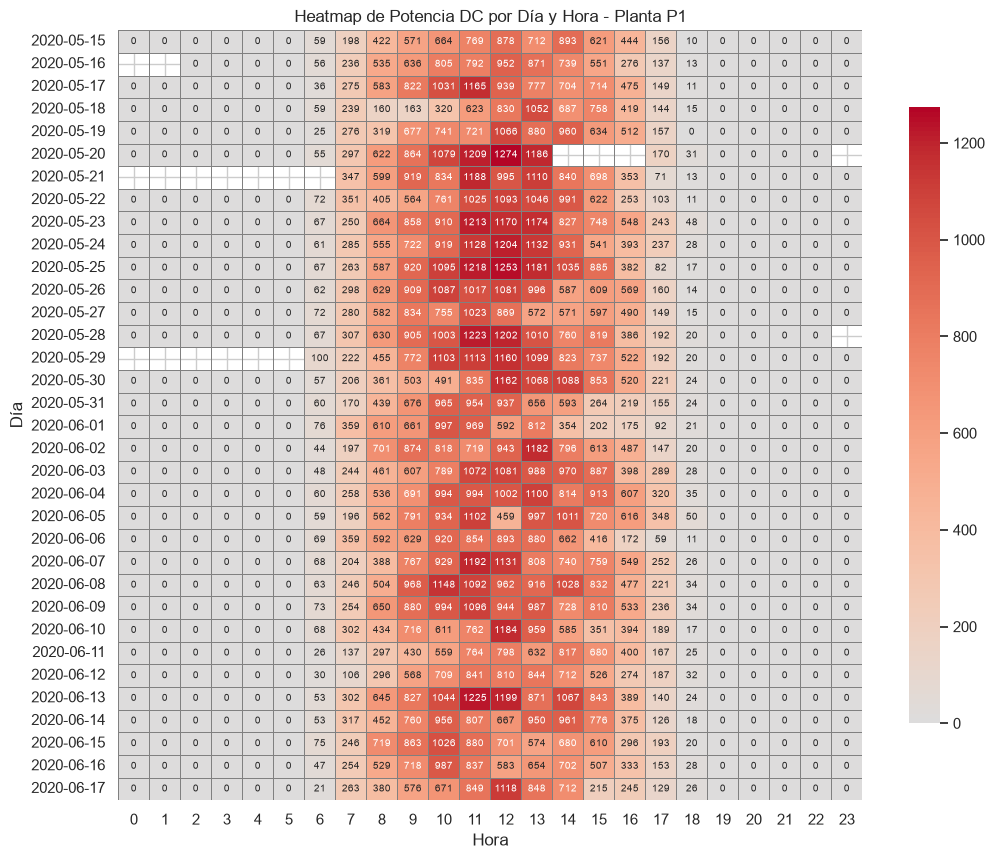

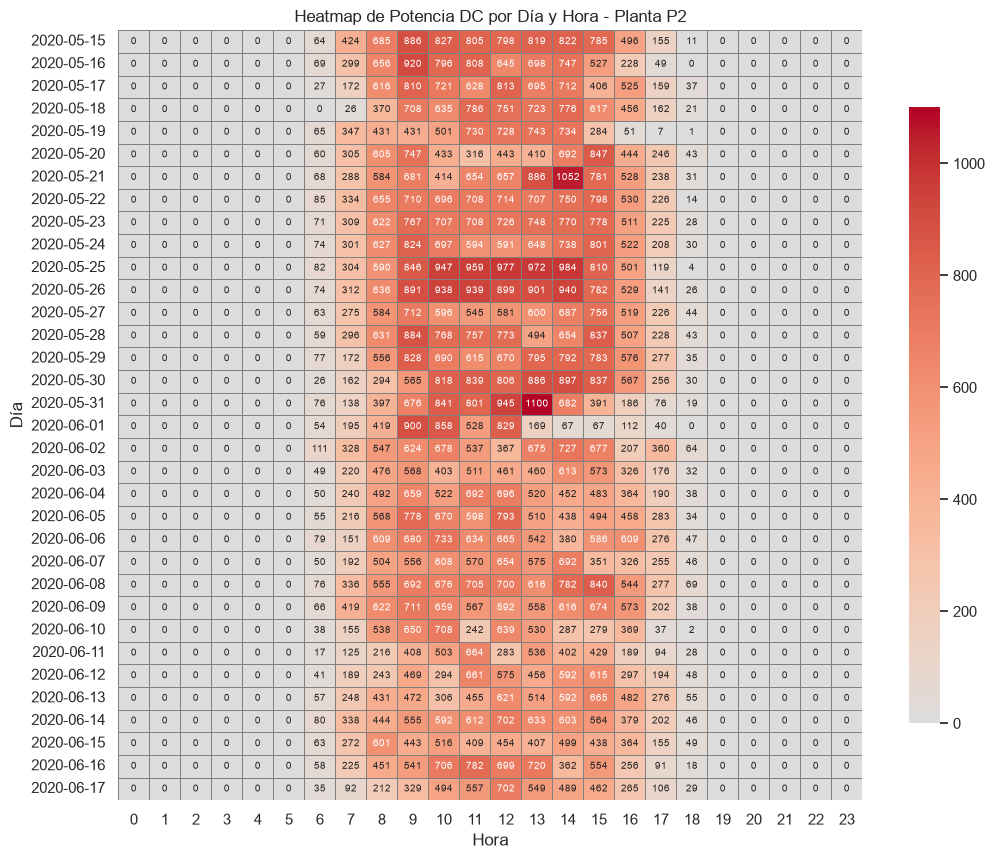

In [155]:
#heatmap de potencia por dia (eje y) y hora (eje x) con potencia como hue usando df_diario_potencia
for planta in ['p1', 'p2']:
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        df_diario_potencia_dc[df_diario_potencia_dc['id_planta'] == planta].
        pivot_table(index='fecha_dia', columns='hora', values='potencia_dc_kw'),
        cmap='coolwarm',
        center=0,
        annot=True,
        fmt=".0f",
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={"shrink": 0.8},
        yticklabels=True,
        annot_kws={"fontsize": 7}
    )
    plt.title(f"Heatmap de Potencia DC por Día y Hora - Planta {planta.upper()}")
    plt.xlabel("Hora")
    plt.ylabel("Día")
    plt.show()

#### Potencia DC VS Energia en plantas 1 y 2

In [162]:
# df diario de irradiacion vs energia generada
df_diario_potencia_energia = (
    df
    .groupby(['fecha', 'id_planta'])[['potencia_dc_kw','energia_diaria_kwh']]
    .agg({
          'potencia_dc_kw': 'sum',
          'energia_diaria_kwh': 'max'
      })
    .reset_index()
)

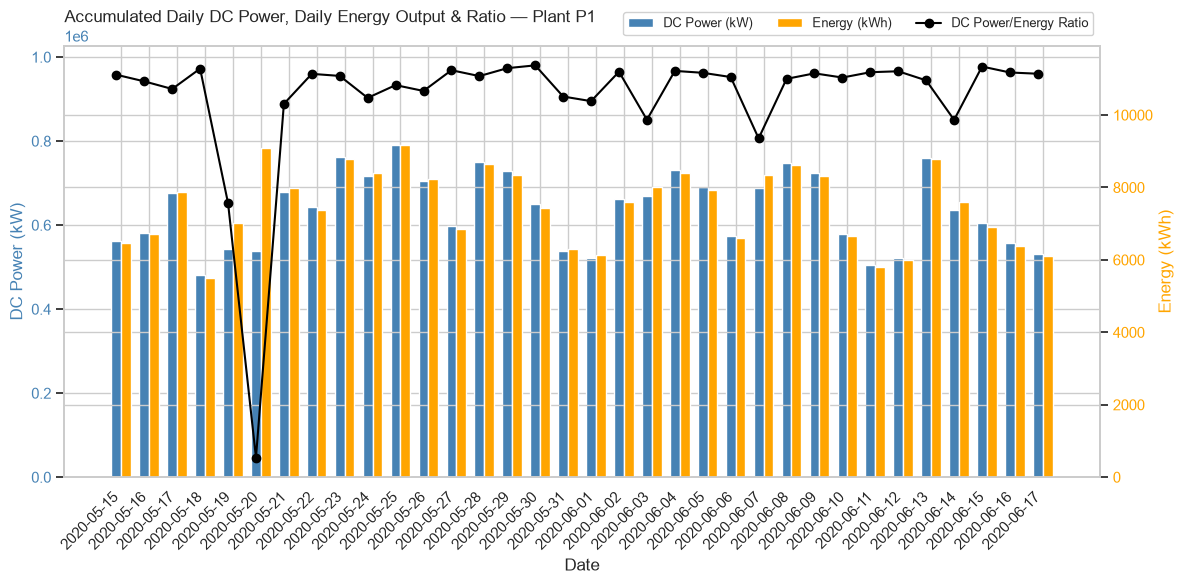

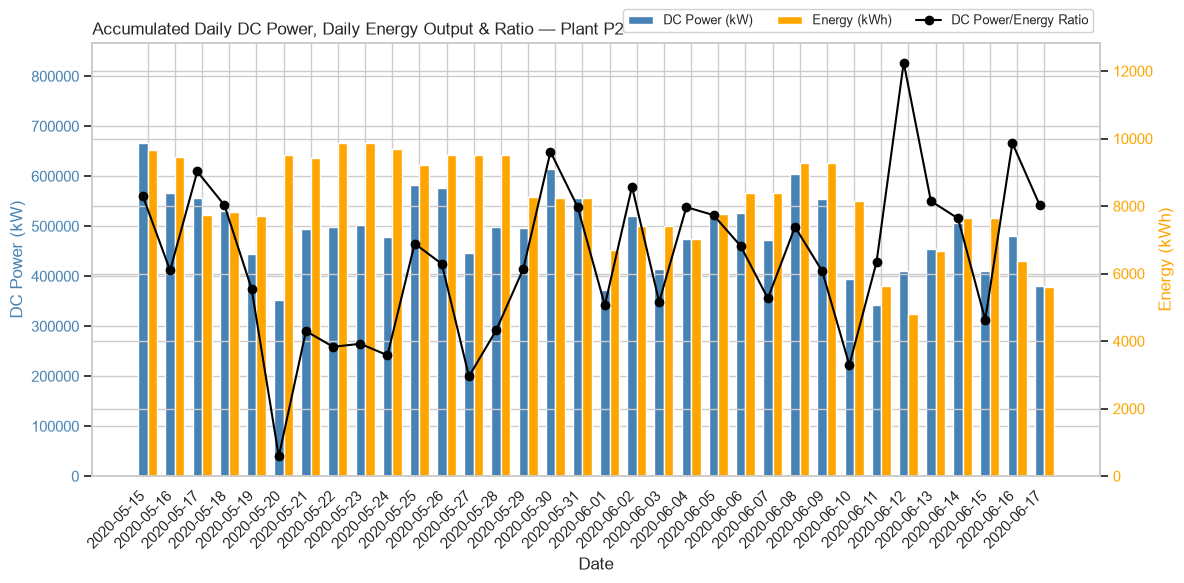

In [198]:
for planta in ['p1', 'p2']:
    df_plot = df_diario_potencia_energia[df_diario_potencia_energia['id_planta'] == planta]
    mediana_ratio = (df_plot['potencia_dc_kw'] / df_plot['energia_diaria_kwh']).median()

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.axis('off')

    bar_width = 0.35
    x = range(len(df_plot))

    ax1.bar(x, df_plot['potencia_dc_kw'], width=bar_width, label='Potencia DC (kW)', color='steelblue')
    ax1.set_ylabel("DC Power (kW)", color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.set_ylim(0, df_plot['potencia_dc_kw'].max() * 1.3)

    ax2.bar([p + bar_width for p in x], df_plot['energia_diaria_kwh'], width=bar_width, label='Energía (kWh)', color='orange')
    ax2.set_ylabel("Energy (kWh)", color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_ylim(0, df_plot['energia_diaria_kwh'].max() * 1.3)

    ratio = df_plot['potencia_dc_kw'] / df_plot['energia_diaria_kwh']
    line_ratio, = ax3.plot(x, ratio, 'o-', color='black', label='Ratio Potencia/Energía')

    ax1.set_xlabel("Date")
    ax1.set_xticks([p + bar_width/2 for p in x])
    ax1.set_xticklabels(df_plot['fecha'].dt.strftime('%Y-%m-%d'), rotation=45, ha='right')

    handles = [ax1.patches[0], ax2.patches[0], line_ratio]
    labels = ['DC Power (kW)', 'Energy (kWh)', 'DC Power/Energy Ratio']
    ax1.legend(handles, labels, loc='lower right', bbox_to_anchor=(1.0, 1.01),
               ncol=3, framealpha=0.9, fontsize=9)

    ax1.set_title(f"Accumulated Daily DC Power, Daily Energy Output & Ratio — Plant {planta.upper()}", loc='left')
    plt.tight_layout()
    plt.show()

#### Análisis de anomalías en Potencia DC registrada por inverter en planta 1 y 2 en días concretos

In [174]:
filter_p1 = (df['id_planta'] == 'p1') & (df['fecha'].isin(pd.to_datetime(['2020-05-19', '2020-05-20'])))
filter_p2 = (df['id_planta'] == 'p2') & (df['fecha'].isin(pd.to_datetime(['2020-05-20', '2020-05-27','2020-06-10', '2020-06-12', '2020-06-15'])))

In [175]:
df_anomalias_inverters_p1 = df[filter_p1].groupby(['fecha', 'hora', 'id_inversor'])[['potencia_dc_kw']].mean().reset_index()
df_anomalias_inverters_p2 = df[filter_p2].groupby(['fecha', 'hora', 'id_inversor'])[['potencia_dc_kw']].mean().reset_index()

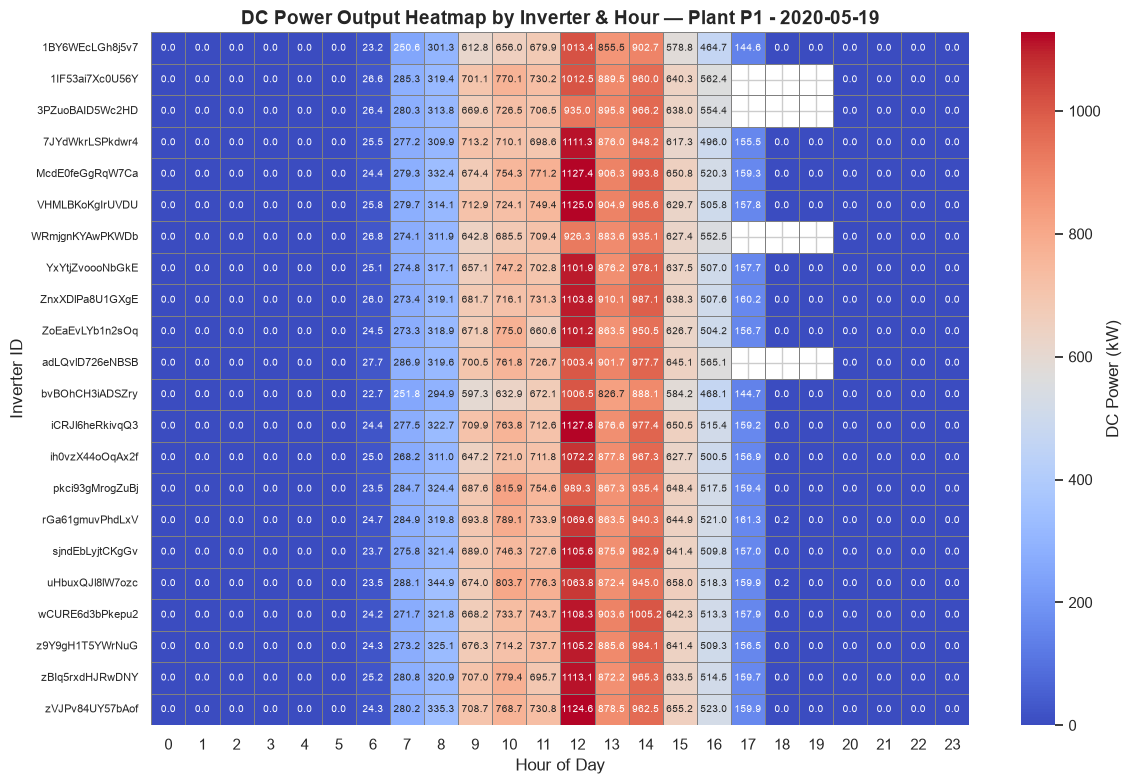

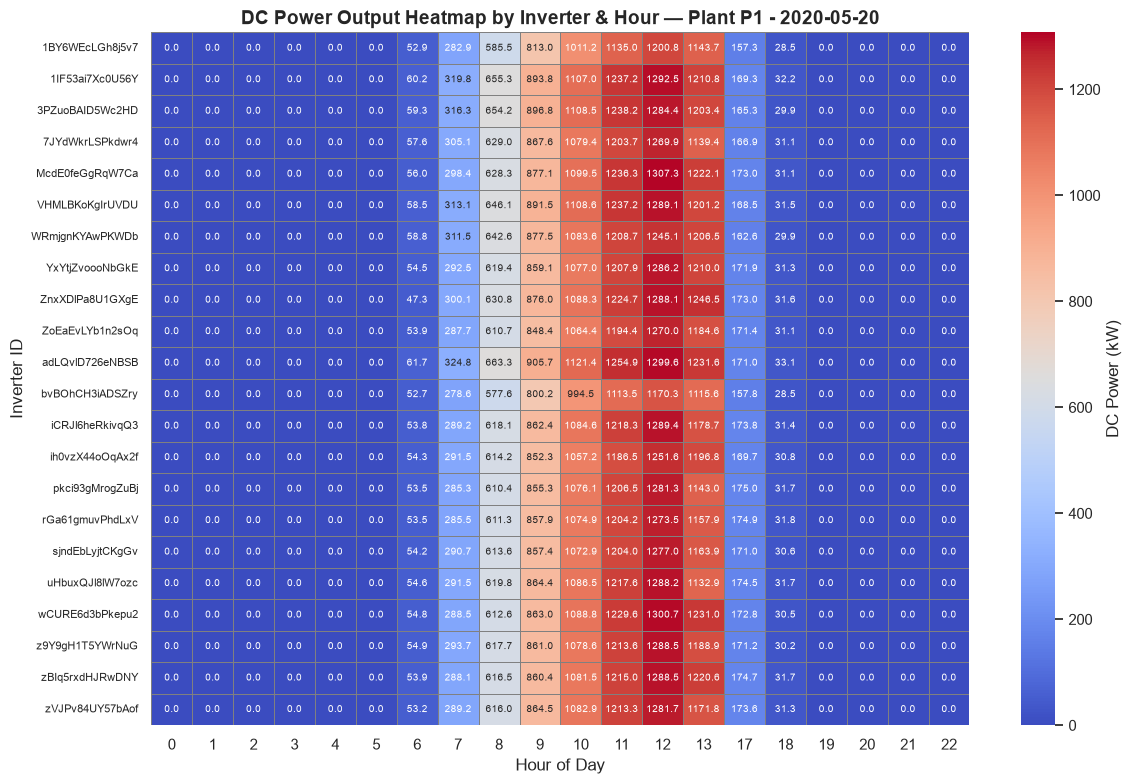

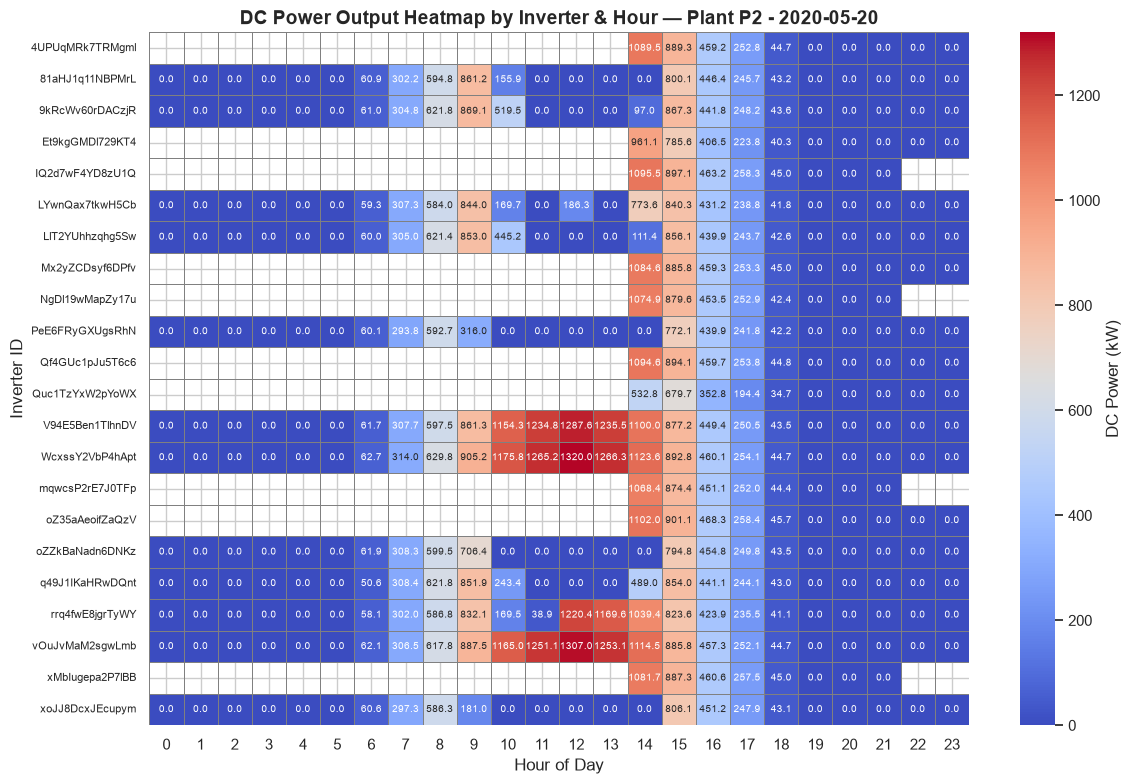

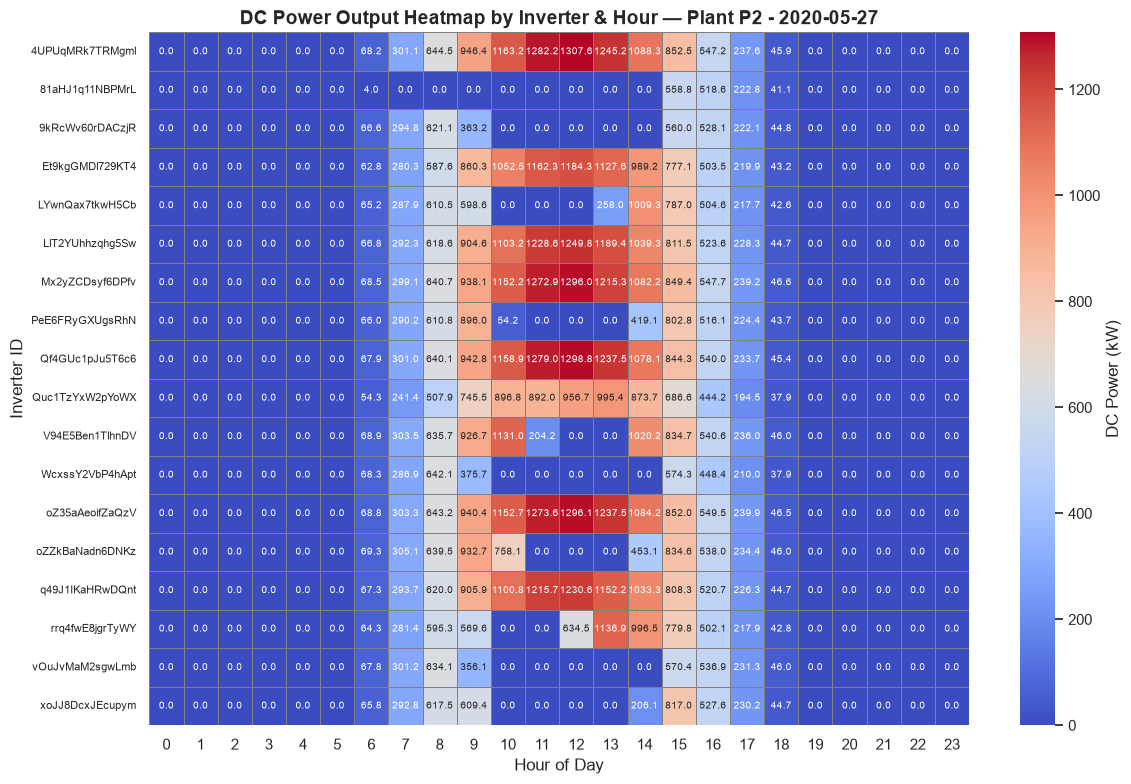

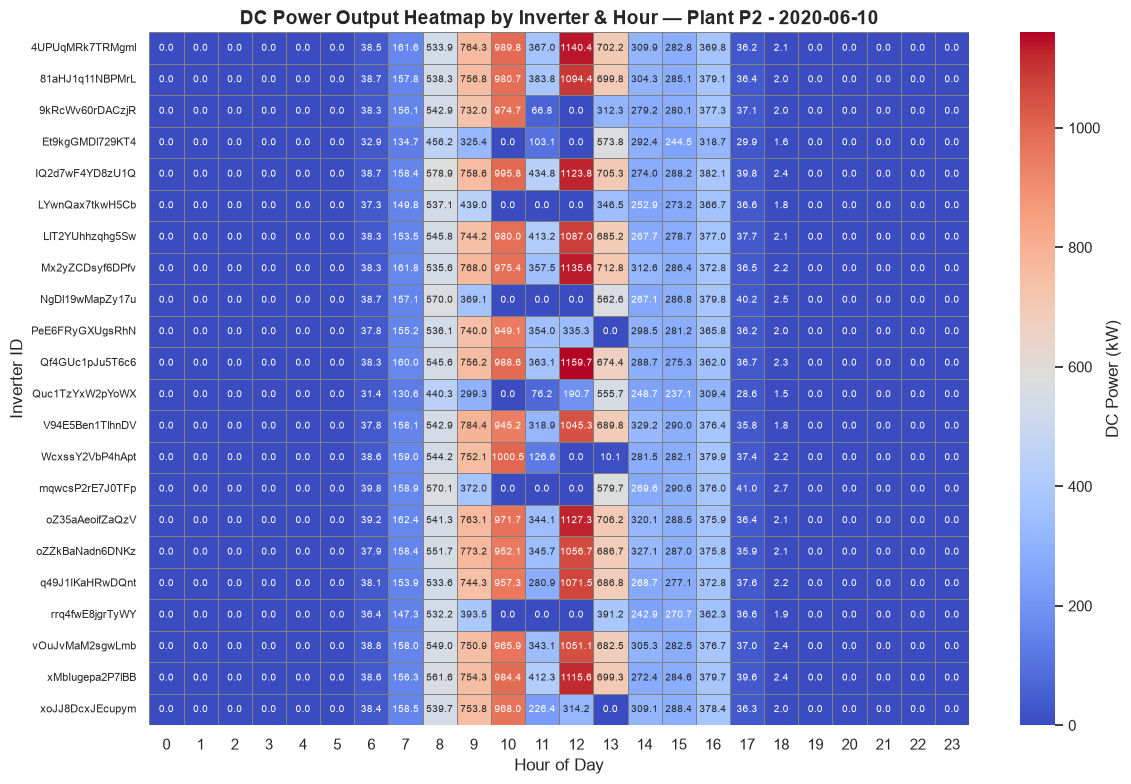

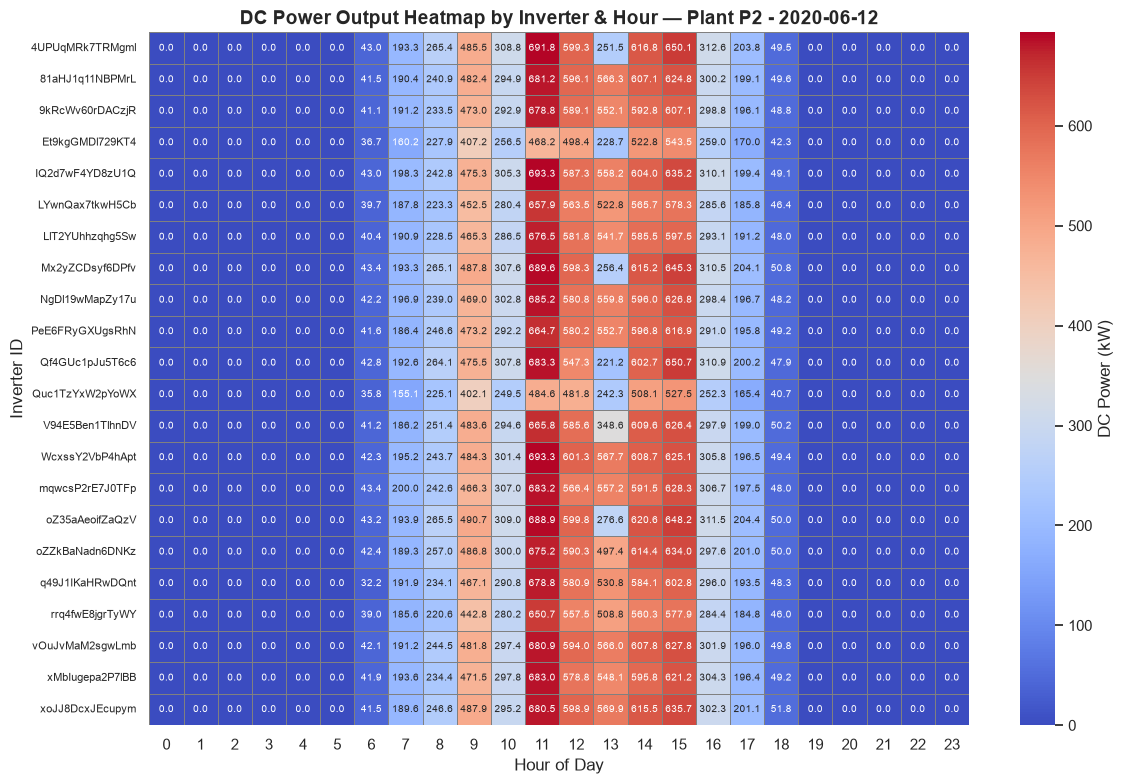

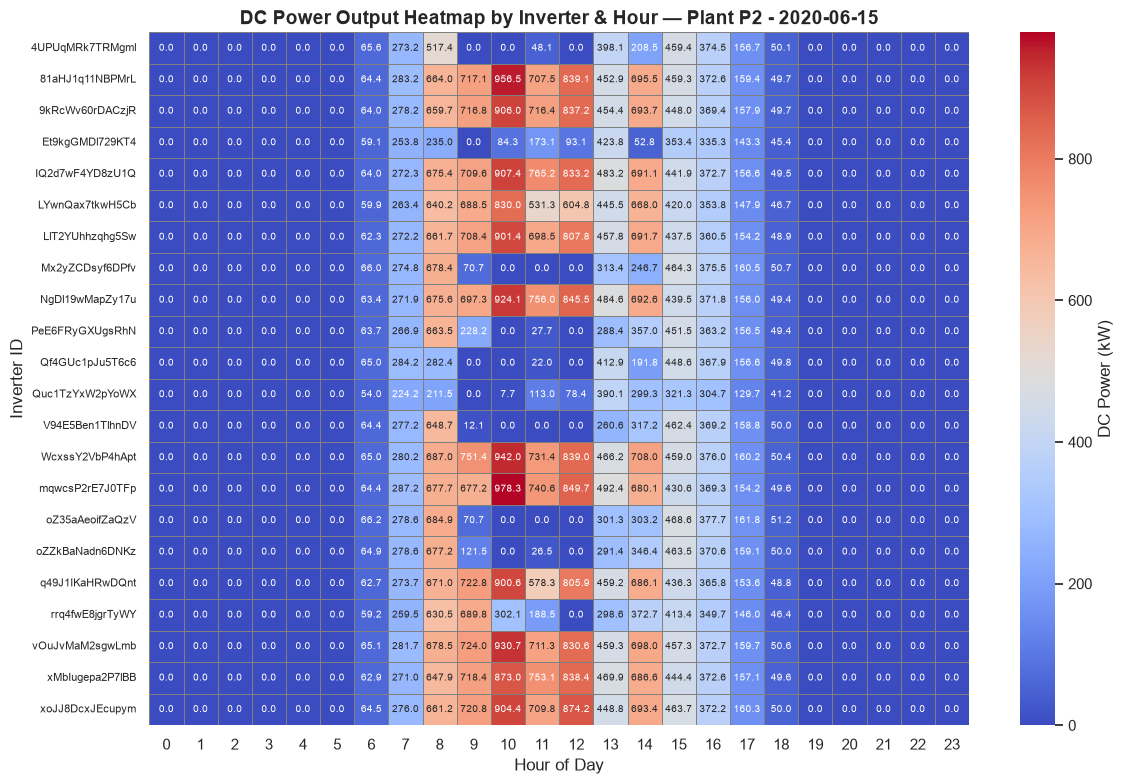

In [196]:
# Crear heatmap para cada día y planta
for planta, df_anomalias in [('p1', df_anomalias_inverters_p1), ('p2', df_anomalias_inverters_p2)]:
    dias_unicos = sorted(df_anomalias['fecha'].unique())

    for dia in dias_unicos:
        df_dia = df_anomalias[df_anomalias['fecha'] == dia]
    
    # Crear pivot table: inverters en Y, horas en X
        pivot_data = df_dia.pivot_table(
            index='id_inversor',
            columns='hora',
            values='potencia_dc_kw',
            aggfunc='mean'
        )
    
        # Crear figura
        plt.figure(figsize=(12, 8))
    
        # Crear heatmap con warm-cold colormap
        ax = sns.heatmap(
            pivot_data,
            cmap='coolwarm',
            annot=True,
            fmt='.1f',
            annot_kws={'size': 7},
            cbar_kws={'label': 'DC Power (kW)'},
            linewidths=0.5,
            linecolor='gray'
        )
        
        # Configurar etiquetas y títulos
        plt.title(f'DC Power Output Heatmap by Inverter & Hour — Plant {planta.upper()} - {pd.Timestamp(dia).strftime("%Y-%m-%d")}', fontsize=14, fontweight='bold')
        plt.xlabel('Hour of Day', fontsize=12)
        plt.ylabel('Inverter ID', fontsize=12)
        plt.xticks(rotation=0)
        plt.yticks(rotation=0, fontsize=8)
        plt.tight_layout()
        
        # Mostrar el heatmap
        plt.show()

In [173]:
#lista de inverters de planta 1 y planta 2 por separado
inverters_p1 = df[df['id_planta'] == 'p1']['id_inversor'].unique()
inverters_p2 = df[df['id_planta'] == 'p2']['id_inversor'].unique()
inverters_p1, inverters_p2

(<StringArray>
 ['1BY6WEcLGh8j5v7', '1IF53ai7Xc0U56Y', '3PZuoBAID5Wc2HD', '7JYdWkrLSPkdwr4',
  'McdE0feGgRqW7Ca', 'VHMLBKoKgIrUVDU', 'WRmjgnKYAwPKWDb', 'ZnxXDlPa8U1GXgE',
  'ZoEaEvLYb1n2sOq', 'adLQvlD726eNBSB', 'bvBOhCH3iADSZry', 'iCRJl6heRkivqQ3',
  'ih0vzX44oOqAx2f', 'pkci93gMrogZuBj', 'rGa61gmuvPhdLxV', 'sjndEbLyjtCKgGv',
  'uHbuxQJl8lW7ozc', 'wCURE6d3bPkepu2', 'z9Y9gH1T5YWrNuG', 'zBIq5rxdHJRwDNY',
  'zVJPv84UY57bAof', 'YxYtjZvoooNbGkE']
 Length: 22, dtype: str,
 <StringArray>
 ['4UPUqMRk7TRMgml', '81aHJ1q11NBPMrL', '9kRcWv60rDACzjR', 'Et9kgGMDl729KT4',
  'IQ2d7wF4YD8zU1Q', 'LYwnQax7tkwH5Cb', 'LlT2YUhhzqhg5Sw', 'Mx2yZCDsyf6DPfv',
  'NgDl19wMapZy17u', 'PeE6FRyGXUgsRhN', 'Qf4GUc1pJu5T6c6', 'Quc1TzYxW2pYoWX',
  'V94E5Ben1TlhnDV', 'WcxssY2VbP4hApt', 'mqwcsP2rE7J0TFp', 'oZ35aAeoifZaQzV',
  'oZZkBaNadn6DNKz', 'q49J1IKaHRwDQnt', 'rrq4fwE8jgrTyWY', 'vOuJvMaM2sgwLmb',
  'xMbIugepa2P7lBB', 'xoJJ8DcxJEcupym']
 Length: 22, dtype: str)

### Insight 6: Fallos de medición de potencia DC/AC en los inverters
Algunos dias presentan niveles de potencia DC descorrelacionada con la energia generada. Esto indica que existen fallos en la medición de dicha potencia por parte de los inverters, descartando la existencia de fallos por desconexión de los mismos.

1. - Planta 1: fallos de medición en 4 inverters concretos el dia 19 de Mayo y fallo de medición de todos los inverters de 14 a 16h el dia 20 de Mayo.
2. - Planta 2: multiples fallos de medición en distintos dias. Se observan fallos bastante distintos tanto por rango de horas como por cantidad de inverters fallando simultaneamente.
        - Días con más fallos: 20 y 27 de Mayo y 10, 12 y 15 de Junio.

### Analisis Profundo de anomalías

#### Bloque 1 — Fallos irradiación

In [187]:
# Ratio por día y planta
df_ratio = df.groupby(['fecha', 'id_planta']).agg(
    irradiacion=('irradiacion_wh_m2', 'sum'),
    energia=('energia_diaria_kwh', 'max')
).reset_index()

df_ratio['ratio'] = df_ratio['irradiacion'] / df_ratio['energia']

def clasificar_ratio(r):
    if r > 0.061 :   return 'normal'
    elif 0.059 <= r <= 0.061 : return 'fallo_leve'
    else: return 'fallo_grave'

df_ratio['clasificacion'] = df_ratio['ratio'].apply(clasificar_ratio)
print(df_ratio[df_ratio['clasificacion'] != 'normal'].sort_values('ratio'))

        fecha id_planta  irradiacion      energia     ratio clasificacion
11 2020-05-20        p2   386.608390  9511.000000  0.040649   fallo_grave
55 2020-06-11        p2   248.115166  5627.066667  0.044093   fallo_grave
10 2020-05-20        p1   401.401929  9102.000000  0.044100   fallo_grave
35 2020-06-01        p2   295.465807  6692.000000  0.044152   fallo_grave
67 2020-06-17        p2   262.696826  5596.000000  0.046944   fallo_grave
39 2020-06-03        p2   365.522035  7404.000000  0.049368   fallo_grave
53 2020-06-10        p2   408.679101  8151.000000  0.050139   fallo_grave
19 2020-05-24        p2   493.668797  9688.000000  0.050957   fallo_grave
63 2020-06-15        p2   390.831026  7634.000000  0.051196   fallo_grave
33 2020-05-31        p2   422.487122  8228.000000  0.051347   fallo_grave
17 2020-05-23        p2   506.879650  9863.000000  0.051392   fallo_grave
23 2020-05-26        p2   490.224131  9501.000000  0.051597   fallo_grave
29 2020-05-29        p2   426.508097  

#### Bloque 2.1 — Ausencia de registros DC por inverter/día

In [180]:
# Horario solar
HORA_INI, HORA_FIN = 6, 20

df_solar = df[(df['hora'] >= HORA_INI) & (df['hora'] <= HORA_FIN)]

# Registros por inverter y día
registros_inv = df_solar.groupby(['fecha', 'id_planta', 'id_inversor'])['potencia_dc_kw'].count().reset_index()
registros_inv.columns = ['fecha', 'id_planta', 'id_inversor', 'n_registros']

# Mediana de registros por día y planta (baseline)
baseline = registros_inv.groupby(['fecha', 'id_planta'])['n_registros'].median().reset_index()
baseline.columns = ['fecha', 'id_planta', 'mediana_registros']

registros_inv = registros_inv.merge(baseline, on=['fecha', 'id_planta'])
registros_inv['pct_registros'] = registros_inv['n_registros'] / registros_inv['mediana_registros']
registros_inv['fallo_ausencia'] = registros_inv['pct_registros'] < 0.5

ausencias = registros_inv[registros_inv['fallo_ausencia']].sort_values(['id_planta', 'fecha'])
print(ausencias[['fecha', 'id_planta', 'id_inversor', 'n_registros', 'mediana_registros', 'pct_registros']])

         fecha id_planta      id_inversor  n_registros  mediana_registros  \
242 2020-05-20        p2  4UPUqMRk7TRMgml           27               60.0   
245 2020-05-20        p2  Et9kgGMDl729KT4           27               60.0   
246 2020-05-20        p2  IQ2d7wF4YD8zU1Q           27               60.0   
249 2020-05-20        p2  Mx2yZCDsyf6DPfv           27               60.0   
250 2020-05-20        p2  NgDl19wMapZy17u           27               60.0   
252 2020-05-20        p2  Qf4GUc1pJu5T6c6           27               60.0   
253 2020-05-20        p2  Quc1TzYxW2pYoWX           27               60.0   
256 2020-05-20        p2  mqwcsP2rE7J0TFp           27               60.0   
257 2020-05-20        p2  oZ35aAeoifZaQzV           27               60.0   
262 2020-05-20        p2  xMbIugepa2P7lBB           27               60.0   
610 2020-05-29        p2  IQ2d7wF4YD8zU1Q           19               59.0   
614 2020-05-29        p2  NgDl19wMapZy17u           19               59.0   

#### Bloque 2.2 — Valores anómalos DC por inverter/hora/día

In [181]:
# Mediana horaria por día y planta
df_solar2 = df[(df['hora'] >= HORA_INI) & (df['hora'] <= HORA_FIN)].copy()

mediana_horaria = df_solar2.groupby(['fecha', 'id_planta', 'hora'])['potencia_dc_kw'].median().reset_index()
mediana_horaria.columns = ['fecha', 'id_planta', 'hora', 'mediana_potencia']

df_solar2 = df_solar2.merge(mediana_horaria, on=['fecha', 'id_planta', 'hora'])

# Anomalía: inverter con potencia < 5% de mediana, mientras mediana > 100kW
df_solar2['anomalia'] = (
    (df_solar2['potencia_dc_kw'] < df_solar2['mediana_potencia'] * 0.05) &
    (df_solar2['mediana_potencia'] > 100)
)

anomalias = df_solar2[df_solar2['anomalia']].groupby(
    ['id_planta', 'id_inversor']
).agg(
    n_horas_anomalas=('anomalia', 'sum'),
    dias_afectados=('fecha', 'nunique')
).reset_index().sort_values(['id_planta', 'n_horas_anomalas'], ascending=[True, False])

print(anomalias)

   id_planta      id_inversor  n_horas_anomalas  dias_afectados
2         p1  bvBOhCH3iADSZry                20               2
0         p1  1BY6WEcLGh8j5v7                19               2
6         p1  z9Y9gH1T5YWrNuG                 7               2
5         p1  wCURE6d3bPkepu2                 5               1
1         p1  McdE0feGgRqW7Ca                 3               1
4         p1  sjndEbLyjtCKgGv                 3               1
7         p1  zBIq5rxdHJRwDNY                 3               2
8         p1  zVJPv84UY57bAof                 2               1
3         p1  ih0vzX44oOqAx2f                 1               1
12        p2  Et9kgGMDl729KT4               294              28
14        p2  LYwnQax7tkwH5Cb               283              24
20        p2  Quc1TzYxW2pYoWX               272              27
27        p2  rrq4fwE8jgrTyWY               241              23
10        p2  81aHJ1q11NBPMrL               220              20
26        p2  q49J1IKaHRwDQnt           

#### Bloque 3 — Ranking final por inverter

In [192]:
# Combinar ausencias + anomalías
ranking_ausencias = ausencias.groupby(['id_planta', 'id_inversor']).agg(
    dias_ausencia=('fecha', 'nunique')
).reset_index()

ranking = anomalias.merge(ranking_ausencias, on=['id_planta', 'id_inversor'], how='outer').fillna(0)
ranking['score_total'] = ranking['n_horas_anomalas'] + ranking['dias_ausencia'] * 5  # peso mayor a ausencias
ranking = ranking.sort_values(['id_planta', 'score_total'], ascending=[True, False])

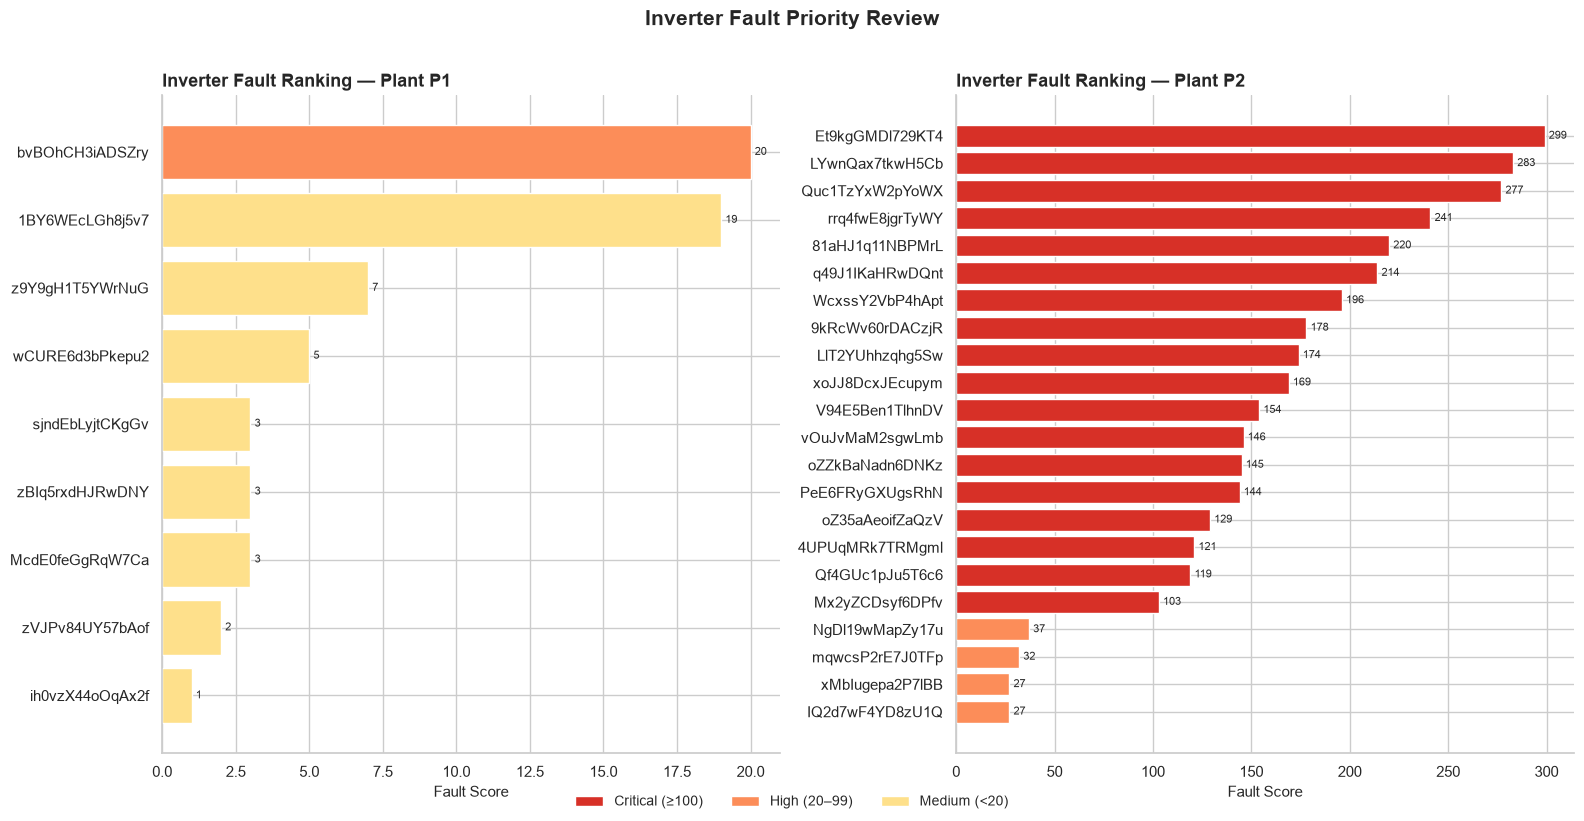

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, planta in zip(axes, ['p1', 'p2']):
    df_plot = ranking[ranking['id_planta'] == planta].sort_values('score_total')
    
    colors = ['#d73027' if s >= 100 else '#fc8d59' if s >= 20 else '#fee08b' 
              for s in df_plot['score_total']]
    
    bars = ax.barh(df_plot['id_inversor'], df_plot['score_total'], color=colors)
    ax.set_xlabel('Fault Score', fontsize=11)
    ax.set_title(f'Inverter Fault Ranking — Plant {planta.upper()}', fontsize=13, fontweight='bold', loc='left')
    ax.bar_label(bars, padding=3, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d73027', label='Critical (≥100)'),
    Patch(facecolor='#fc8d59', label='High (20–99)'),
    Patch(facecolor='#fee08b', label='Medium (<20)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, frameon=False)

plt.suptitle('Inverter Fault Priority Review', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/graphics/inverter-fault-ranking.png', dpi=150, bbox_inches='tight')
plt.show()